In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install timm pandas scikit-learn matplotlib tqdm

In [ ]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive"))

True


In [ ]:
import os

zip_name = "aapke_havale_vatan_sathiyo.zip"

zip_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if zip_name in files:
        zip_path = os.path.join(root, zip_name)
        break

print(zip_path)

None


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".zip"):
            print(file)

240195.zip


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/DeepFakeProject/data"))

[]


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/DeepFakeProject/data"))

['Copy of aapke_havale_vatan_sathiyo.zip']


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DeepFakeProject/data/Copy of aapke_havale_vatan_sathiyo.zip"
extract_path = "/content/drive/MyDrive/DeepFakeProject/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/DeepFakeProject/data/master_faces.csv"))

False


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/DeepFakeProject/data"))

['Copy of aapke_havale_vatan_sathiyo.zip', 'handover']


In [ ]:
print(os.listdir("/content/drive/MyDrive/DeepFakeProject/data/handover"))

['audit.py', 'cleanup.py', 'count_frames.py', 'crop_faces.py', 'data', 'master_faces.csv', 'process_data.py', 'test.json', 'train.json', 'val.json']


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/DeepFakeProject/data/handover/master_faces.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)
print(df.shape)

                                   image_path  label split manipulation
0  data/faces/DeepFakes/test/000_003/0000.jpg      1  test    DeepFakes
1  data/faces/DeepFakes/test/000_003/0001.jpg      1  test    DeepFakes
2  data/faces/DeepFakes/test/000_003/0002.jpg      1  test    DeepFakes
3  data/faces/DeepFakes/test/000_003/0003.jpg      1  test    DeepFakes
4  data/faces/DeepFakes/test/000_003/0004.jpg      1  test    DeepFakes
Index(['image_path', 'label', 'split', 'manipulation'], dtype='object')
(89485, 4)


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class DeepfakeDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

        self.base_path = "/content/drive/MyDrive/DeepFakeProject/data/handover"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(self.base_path, row["image_path"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = float(row["label"])

        return image, label

In [ ]:
train_df = df[df["split"]=="train"]

val_df = df[df["split"]=="val"]

test_df = df[df["split"]=="test"]

print(len(train_df), len(val_df), len(test_df))

64519 12508 12458


In [ ]:
from torch.utils.data import DataLoader

train_dataset = DeepfakeDataset(train_df, train_transform)
val_dataset = DeepfakeDataset(val_df, test_transform)
test_dataset = DeepfakeDataset(test_df, test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Done")

Done


In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([0., 1., 0., 1., 1., 1., 1., 0., 1., 1.], dtype=torch.float64)


In [ ]:
import timm
import torch
import torch.nn as nn

class EfficientNetB0(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=0
        )

        self.classifier = nn.Linear(1280, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetB0().to(device)

print(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

cuda


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4
)

In [ ]:
print(model)

EfficientNetB0(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw)

In [ ]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import torch

best_auc = 0.0

train_losses = []
val_losses = []
val_aucs = []

epochs = 20

for epoch in range(epochs):

    ##############################
    # TRAIN
    ##############################

    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    ##############################
    # VALIDATION
    ##############################

    model.eval()

    running_loss = 0

    predictions = []
    targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            predictions.extend(probs.cpu().numpy())

            targets.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)

    val_losses.append(val_loss)

    auc = roc_auc_score(targets, predictions)

    val_aucs.append(auc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val AUC    : {auc:.4f}")

    if auc > best_auc:

        best_auc = auc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/DeepFakeProject/checkpoints/efficientnet_b0.pth"
        )

        print("Best model saved!")

100%|██████████| 2017/2017 [10:20<00:00,  3.25it/s]



Epoch 1/20
Train Loss : 0.0399
Val Loss   : 0.0503
Val AUC    : 0.9984
Best model saved!


100%|██████████| 2017/2017 [09:41<00:00,  3.47it/s]



Epoch 2/20
Train Loss : 0.0143
Val Loss   : 0.0595
Val AUC    : 0.9983


100%|██████████| 2017/2017 [09:16<00:00,  3.62it/s]


...


Epoch 18/20
Train Loss : 0.0014
Val Loss   : 0.0633
Val AUC    : 0.9990


100%|██████████| 2017/2017 [07:28<00:00,  4.50it/s]



Epoch 19/20
Train Loss : 0.0017
Val Loss   : 0.0389
Val AUC    : 0.9994


100%|██████████| 2017/2017 [07:28<00:00,  4.50it/s]



Epoch 20/20
Train Loss : 0.0026
Val Loss   : 0.0292
Val AUC    : 0.9997


In [ ]:
import pandas as pd
import torch

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DeepFakeProject/checkpoints/efficientnet_b0.pth"
    )
)

model.eval()

predictions = []
labels = []
paths = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        image, label = test_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        probability = torch.sigmoid(output).item()

        predictions.append(probability)
        labels.append(label)
        paths.append(test_df.iloc[i]["image_path"])

pred_df = pd.DataFrame({
    "image_path": paths,
    "true_label": labels,
    "fake_score": predictions
})

pred_df.to_csv(
    "/content/drive/MyDrive/DeepFakeProject/outputs/efficientnet_predictions.csv",
    index=False
)

print("Prediction file saved!")

Prediction file saved!


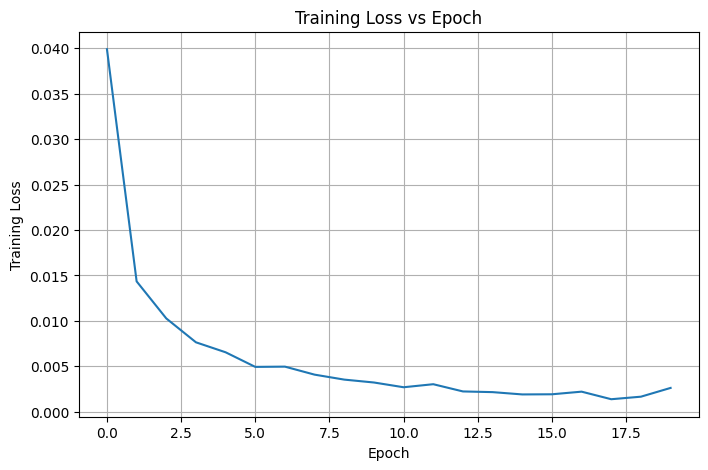

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/DeepFakeProject/outputs/loss.png")

plt.show()

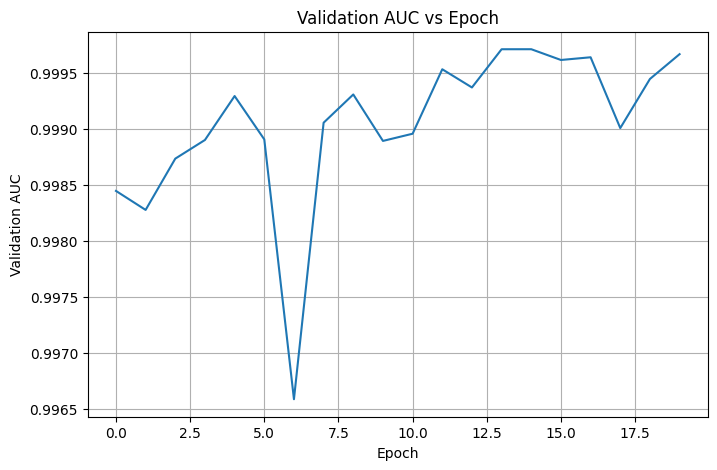

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(val_aucs)
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC vs Epoch")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/DeepFakeProject/outputs/auc.png")

plt.show()

In [ ]:
import torch
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image

class EfficientNetB0(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=False,
            num_classes=0
        )

        self.classifier = nn.Linear(1280,1)

    def forward(self,x):
        x=self.backbone(x)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetB0()
checkpoint = torch.load(
    "/content/drive/MyDrive/DeepFakeProject/checkpoints/efficientnet_b0.pth",
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

def get_fake_score(image_path):

    img = Image.open(image_path).convert("RGB")

    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        probability = torch.sigmoid(output).item()

    return probability

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/DeepFakeProject/checkpoints"))

['efficientnet_b0.pth']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/DeepFakeProject/outputs"))

['efficientnet_predictions.csv', 'loss.png', 'auc.png']
